<h1 style="text-align: center;">Pharma Sales Data Cleaning Process Flow</h1> 

## 0. Libraries

In [1]:
import pandas as pd
import numpy as np 
import missingno as msno
import matplotlib.pyplot as plt

## 1.  Call Defined Functions

In [2]:
from portfolio_data_cleaning_functions import seasonal_average_daily,seasonal_average_hourly,detect_and_replace_outliers

## 2. Read CSVs 

In [3]:
salesdaily=pd.read_csv('~/Portfolio/salesdaily.csv' , sep=";")
saleshourly=pd.read_csv('~/Portfolio/saleshourly.csv', sep=";")
salesmonthly=pd.read_csv('~/Portfolio/salesmonthly.csv', sep=";")
salesweekly=pd.read_csv('~/Portfolio/salesweekly.csv' , sep=";")
countrycode=pd.read_csv('~/Portfolio/countrycodes.csv' , sep=";")

In [4]:
salesdailys = {
    "SalesHourly": saleshourly,
    "SalesDaily": salesdaily,
    "SalesWeekly": salesweekly,
    "SalesMonthly": salesmonthly,
    "CountryCode": countrycode,
}


In [5]:
print(salesdaily)

           datum  M01AB   M01AE  N02BA  N02BE  N05B  N05C  R03HU  R06AE  Year  \
0     2014.01.02   0.00   3.670   3.40  32.40   7.0   0.0    0.0   2.00  2014   
1     2014.01.03   8.00   4.000   4.40  50.60  16.0   0.0   20.0   4.00  2014   
2     2014.01.04   2.00   1.000   6.50  61.85  10.0   0.0    9.0   1.00  2014   
3     2014.01.05   4.00   3.000   7.00  41.10   8.0   0.0    3.0   0.00  2014   
4     2014.01.06   5.00   1.000   4.50  21.70  16.0   2.0    6.0   2.00  2014   
...          ...    ...     ...    ...    ...   ...   ...    ...    ...   ...   
2101  2019.10.04   7.34   5.683   2.25  22.45  13.0   0.0    1.0   1.00  2019   
2102  2019.10.05   3.84   5.010   6.00  25.40   7.0   0.0    0.0   0.33  2019   
2103  2019.10.06   4.00  11.690   2.00  34.60   6.0   0.0    5.0   4.20  2019   
2104  2019.10.07   7.34   4.507   3.00  50.80   6.0   0.0   10.0   1.00  2019   
2105  2019.10.08   0.33   1.730   0.50  44.30  20.0   2.0    2.0   0.00  2019   

      Month  Hour Weekday N

In [6]:
saleshourly.rename(columns={"datum": "date"}, inplace=True)
saleshourly["date"] = pd.to_datetime(saleshourly["date"] )
salesdaily.rename(columns={"datum": "date"}, inplace=True)
salesdaily["date"] = pd.to_datetime(salesdaily["date"] )
salesweekly.rename(columns={"datum": "date"}, inplace=True)
salesweekly["date"] = pd.to_datetime(salesweekly["date"])
salesmonthly.rename(columns={"datum": "date"}, inplace=True)
salesmonthly["date"] = pd.to_datetime(salesmonthly["date"])

## 3. Checking Missing Values 

Check how many 0 values are in the data sets. If there are 0-s in it then my suggestion is NA-s are mistaken missing and I make a seasonal imputation. If there are no 0 values in the data set, I will replace the missing values with 0 with the concept at that time there was not an sales.

In [7]:
for name, sales in salesdailys.items():
    print(f"\n{name} DataFrame:")
    
    null_counts = sales.isna().sum()
    null_counts = null_counts[null_counts > 0]
    zero_counts = (sales == 0).sum()
    zero_percentage = (sales == 0).mean() * 100
    
    if not null_counts.empty:
        print("Columns with missing values:")
        print(null_counts)
        print("Zeros:")
        print(zero_counts)
        print("Zero percentage:", round(zero_percentage, 2), "%")

    else:
        print("No missing values.")


SalesHourly DataFrame:
Columns with missing values:
N05B     417
N05C      57
R03HU    147
R06AE    392
dtype: int64
Zeros:
date                0
M01AB           41633
M01AE           41017
N02BA           43086
N02BE           30130
N05B            39974
N05C            49668
R03HU           47120
R06AE           45247
Year                0
Month               0
Hour             2105
Weekday Name        0
dtype: int64
Zero percentage: date             0.00
M01AB           82.39
M01AE           81.17
N02BA           85.26
N02BE           59.63
N05B            79.11
N05C            98.29
R03HU           93.25
R06AE           89.54
Year             0.00
Month            0.00
Hour             4.17
Weekday Name     0.00
dtype: float64 %

SalesDaily DataFrame:
Columns with missing values:
N05B     67
N05C     27
R03HU    38
dtype: int64
Zeros:
date               0
M01AB             40
M01AE             36
N02BA             78
N02BE             26
N05B              43
N05C            1430
R

Since zero sales occur naturally in the dataset, missing values were treated as data gaps and imputed using seasonal imputation.

### 3.2 Imputation

In [8]:
salesdaily.info()
print(salesdaily)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2039 non-null   float64       
 6   N05C          2079 non-null   float64       
 7   R03HU         2068 non-null   float64       
 8   R06AE         2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 214.0+ KB
           date  M01AB   M01AE  N02BA  N02BE  N05B  N05C  R0

In [9]:
salesdaily = salesdaily.set_index("date", drop=False)

salesdaily = seasonal_average_daily(salesdaily,column="N05B")
salesdaily = seasonal_average_daily(salesdaily,column="N05C")
salesdaily = seasonal_average_daily(salesdaily,column="R03HU")
salesdaily = seasonal_average_daily(salesdaily,column="R06AE")


saleshourly = saleshourly.set_index("date", drop=False)
saleshourly = seasonal_average_hourly(saleshourly,column="N05B")
saleshourly = seasonal_average_hourly(saleshourly,column="N05C")
saleshourly = seasonal_average_hourly(saleshourly,column="R03HU")

salesweekly = salesweekly.set_index("date", drop=False)
salesmonthly = salesmonthly.set_index("date", drop=False)


## 4. Check Duplicates

In [10]:
salesdaily.duplicated().any()
saleshourly.duplicated().any()
salesweekly.duplicated().any()
salesmonthly.duplicated().any()

np.False_

## 5. Check Data Types

In [11]:
salesdaily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2106 entries, 2014-01-02 to 2019-10-08
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03HU         2106 non-null   float64       
 8   R06AE         2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 230.3+ KB


Date column is an object, which si not correct so i convert it to date format 

In [12]:
salesdaily["date"] = pd.to_datetime(salesdaily["date"])

In [13]:
saleshourly["date"] = pd.to_datetime(saleshourly["date"])
salesweekly["date"] = pd.to_datetime(salesweekly["date"])
salesmonthly["date"] = pd.to_datetime(salesmonthly["date"])

 ## 6. Outliers

In [14]:
##Q1 = salesdaily["N05B"].quantile(0.25)
##Q3 = salesdaily["N05B"].quantile(0.75)
##IQR = Q3 - Q1

##lower = Q1 - 1.5 * IQR
##upper = Q3 + 1.5 * IQR

##salesdaily["is_outlier"] = (salesdaily["N05B"] < lower) | (salesdaily["N05B"] > upper)

<Figure size 1200x600 with 0 Axes>

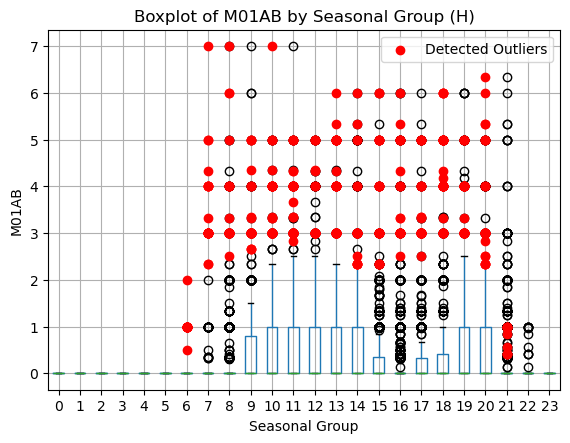

<Figure size 1200x600 with 0 Axes>

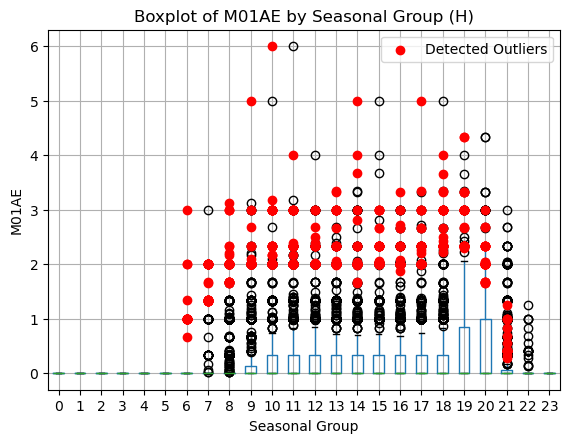

<Figure size 1200x600 with 0 Axes>

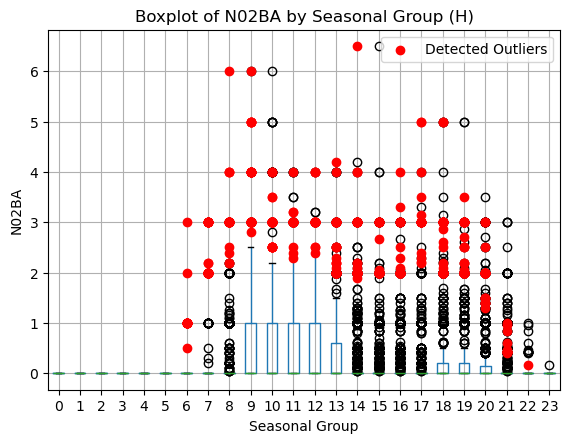

<Figure size 1200x600 with 0 Axes>

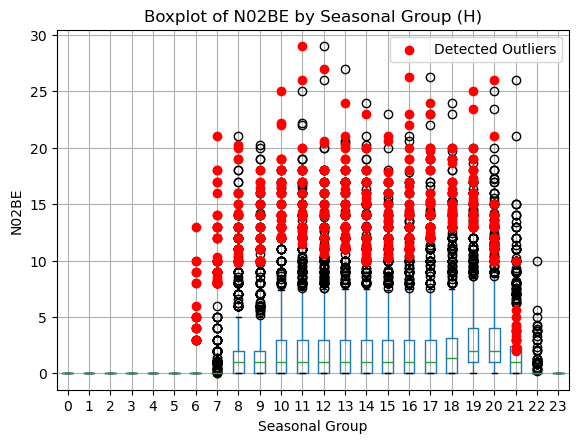

<Figure size 1200x600 with 0 Axes>

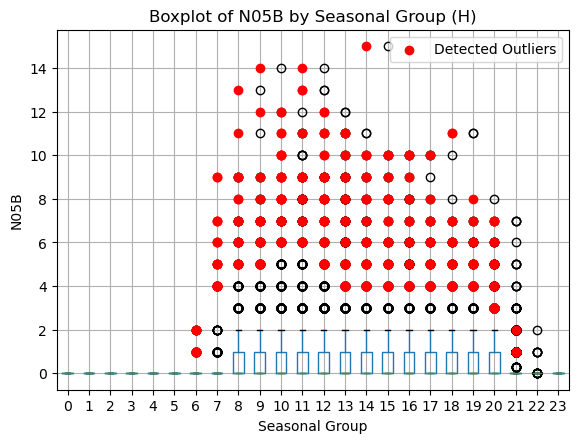

<Figure size 1200x600 with 0 Axes>

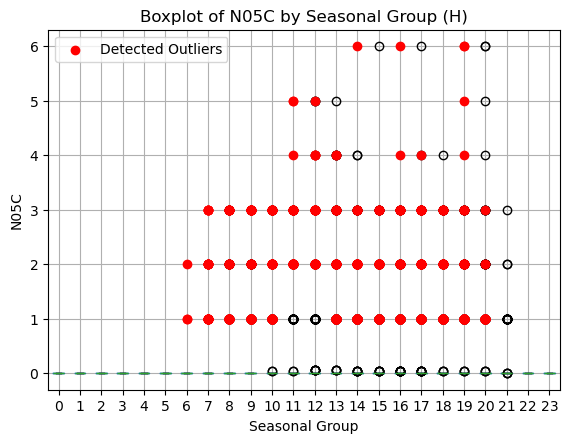

<Figure size 1200x600 with 0 Axes>

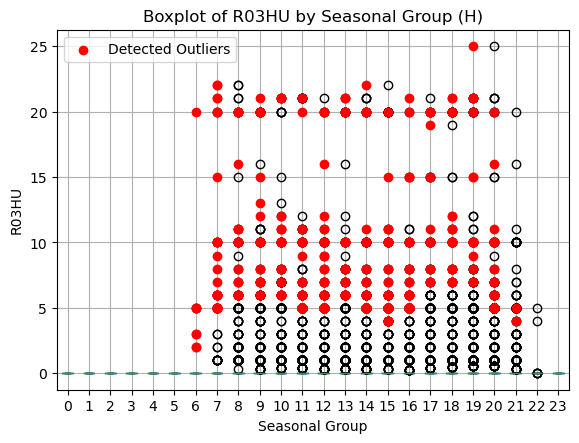

<Figure size 1200x600 with 0 Axes>

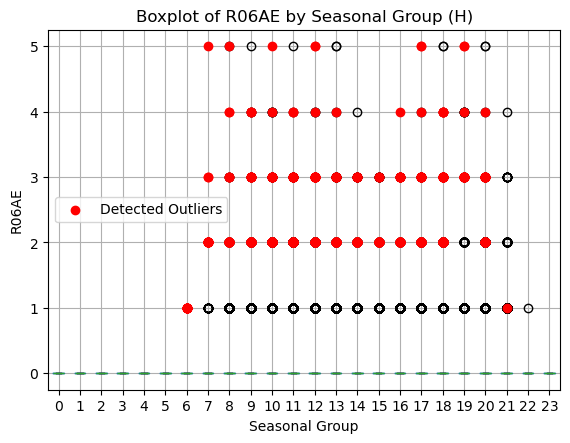

In [15]:
atc_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03HU", "R06AE"]
for i in atc_columns:
    saleshourly = detect_and_replace_outliers(saleshourly, i, "H")


Outliers were initially identified using the three-sigma rule. However, since the dataset represents seasonal sales time series, detected extreme values were further evaluated against temporal patterns. Many observations reflected genuine demand variability rather than data errors; therefore, no automatic removal was applied.

<Figure size 1200x600 with 0 Axes>

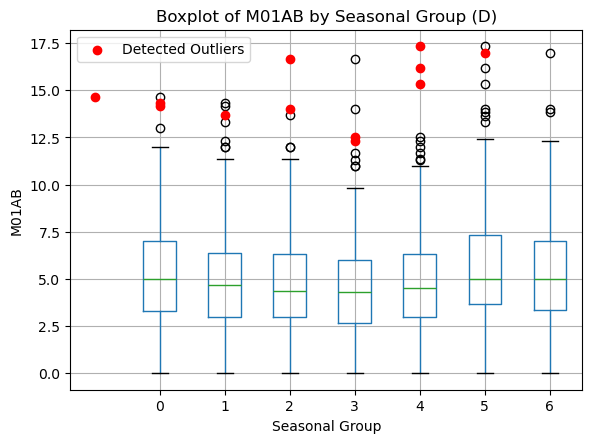

<Figure size 1200x600 with 0 Axes>

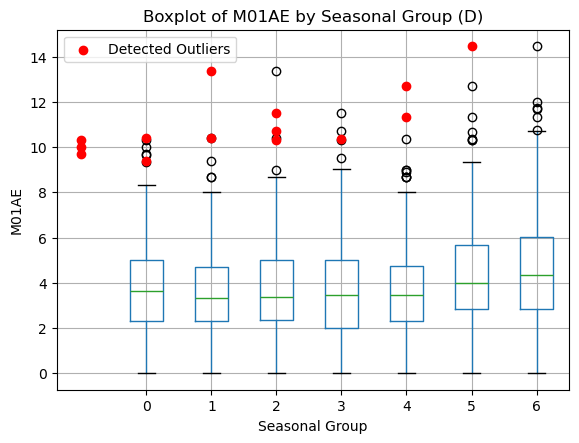

<Figure size 1200x600 with 0 Axes>

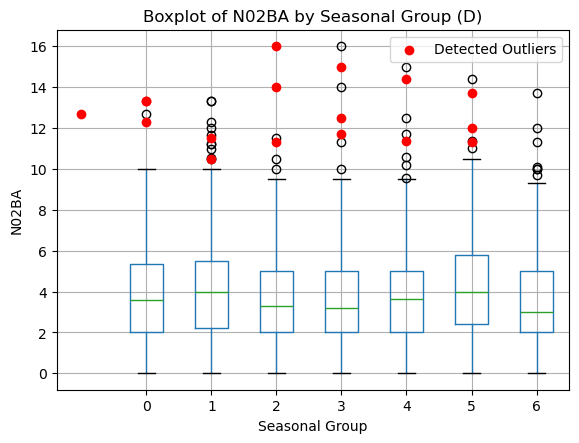

<Figure size 1200x600 with 0 Axes>

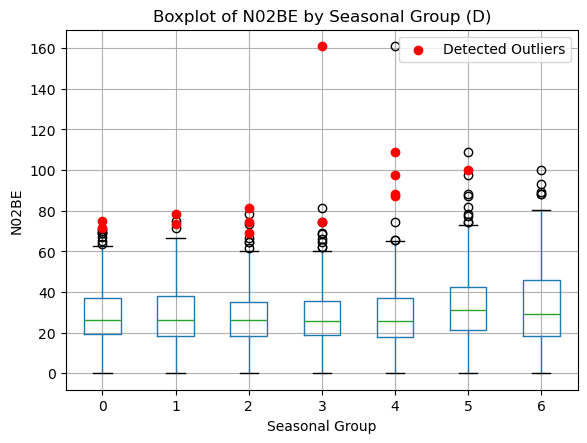

<Figure size 1200x600 with 0 Axes>

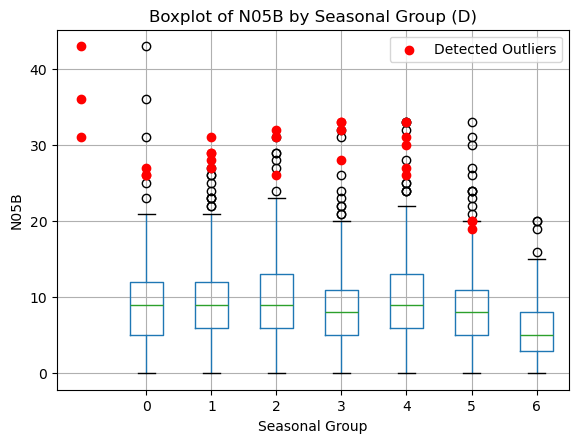

<Figure size 1200x600 with 0 Axes>

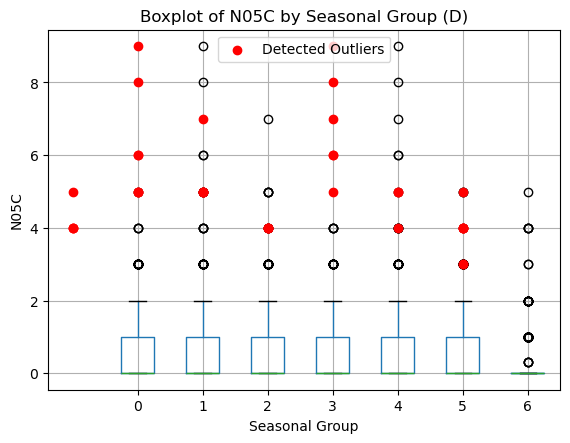

<Figure size 1200x600 with 0 Axes>

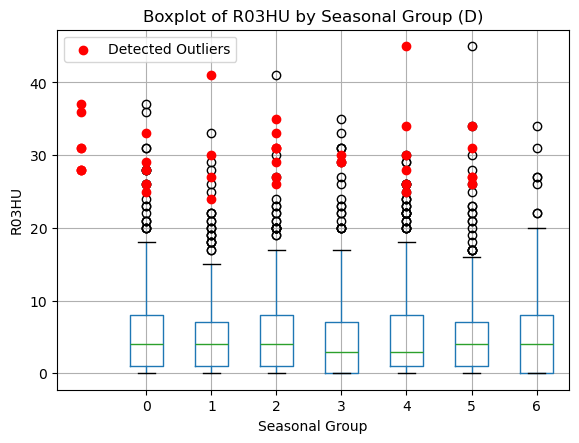

<Figure size 1200x600 with 0 Axes>

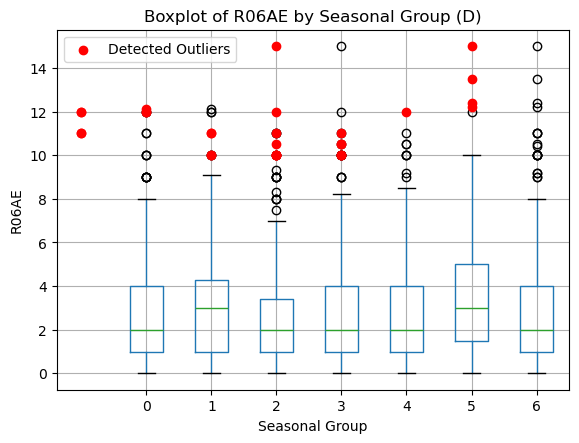

<Figure size 1200x600 with 0 Axes>

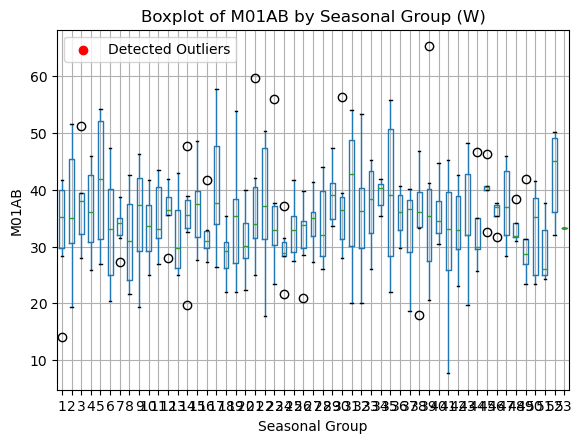

<Figure size 1200x600 with 0 Axes>

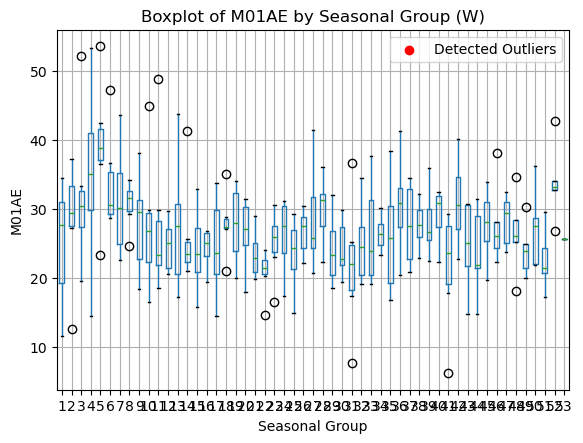

<Figure size 1200x600 with 0 Axes>

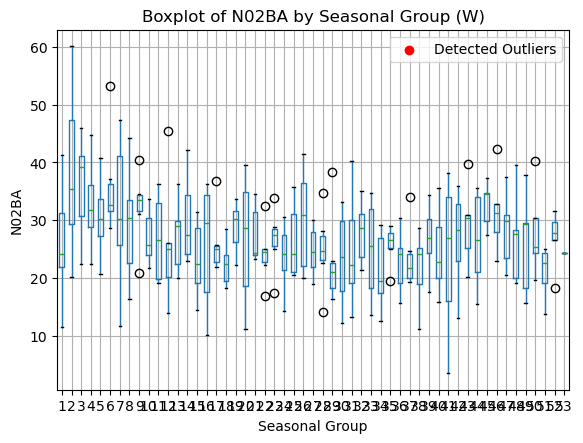

<Figure size 1200x600 with 0 Axes>

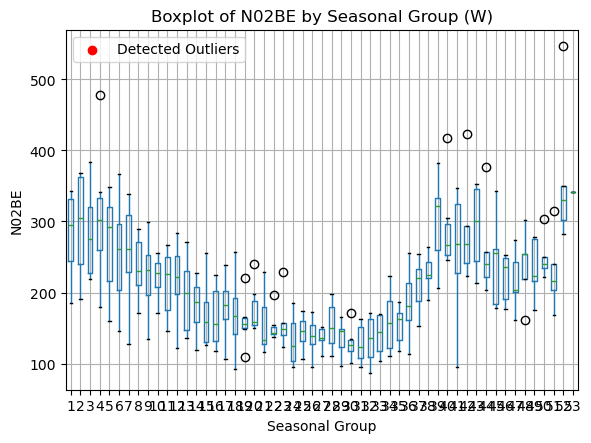

<Figure size 1200x600 with 0 Axes>

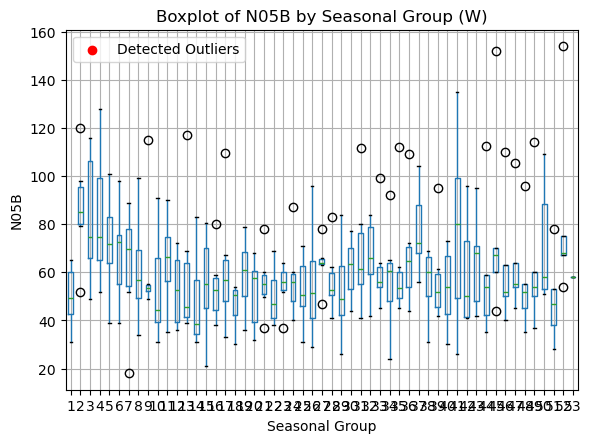

<Figure size 1200x600 with 0 Axes>

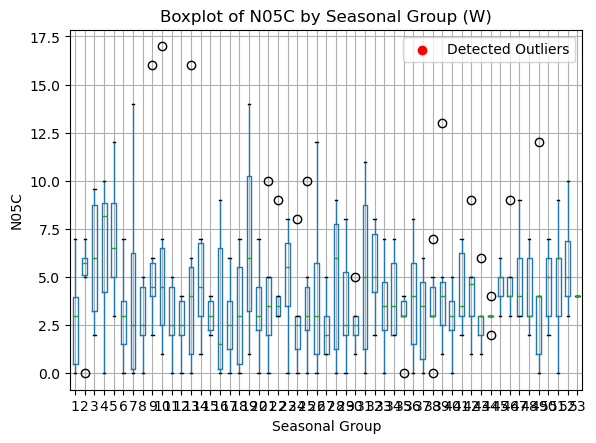

<Figure size 1200x600 with 0 Axes>

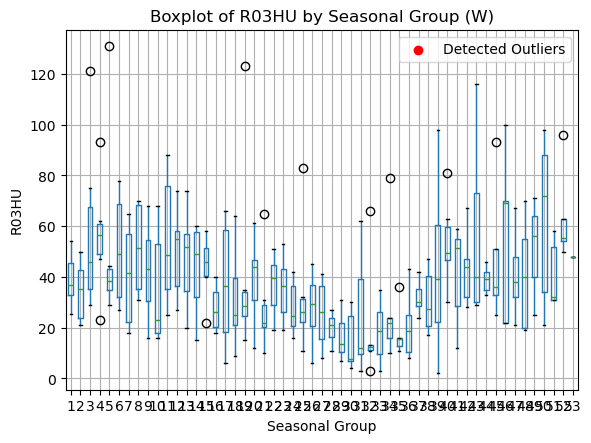

<Figure size 1200x600 with 0 Axes>

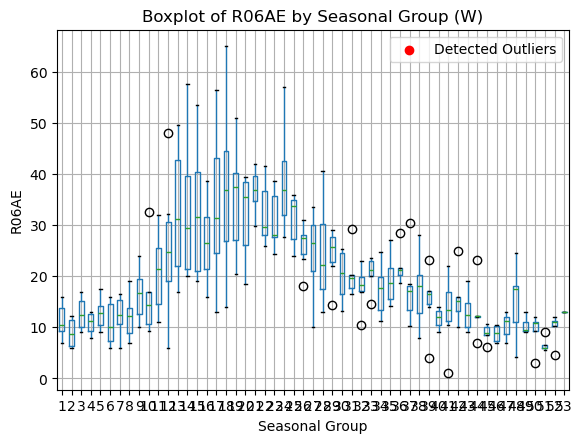

<Figure size 1200x600 with 0 Axes>

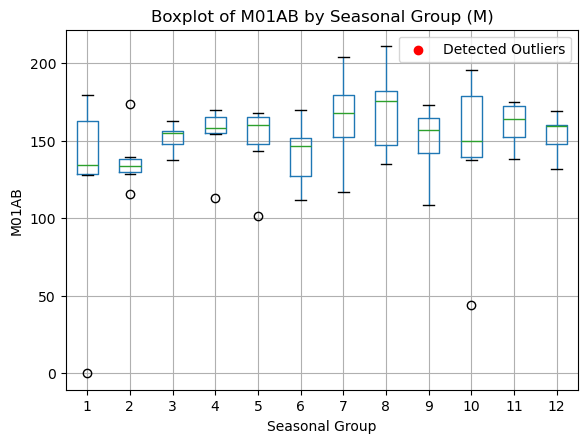

<Figure size 1200x600 with 0 Axes>

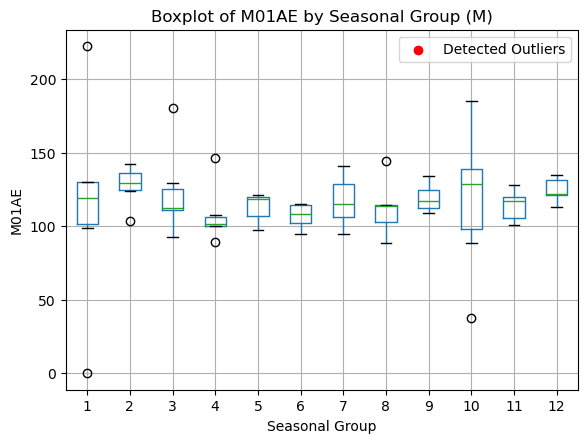

<Figure size 1200x600 with 0 Axes>

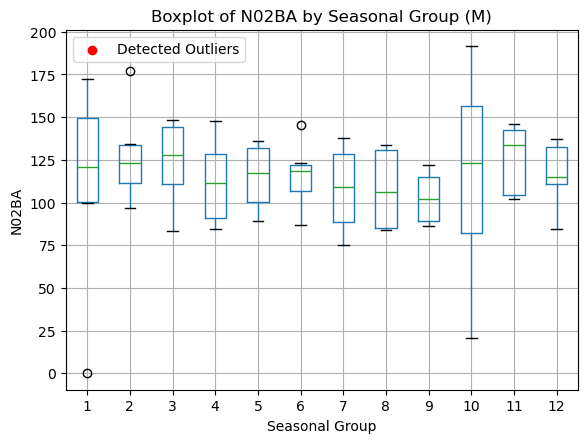

<Figure size 1200x600 with 0 Axes>

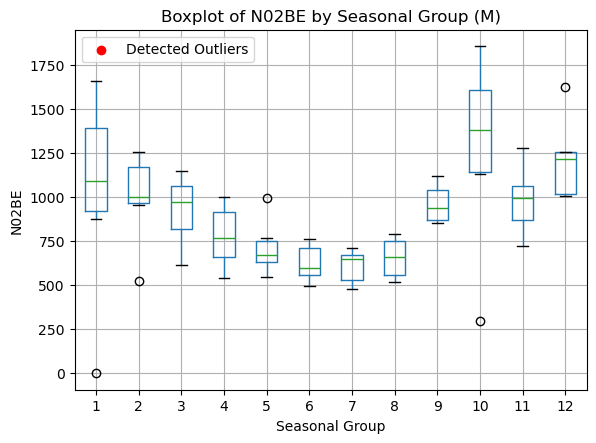

<Figure size 1200x600 with 0 Axes>

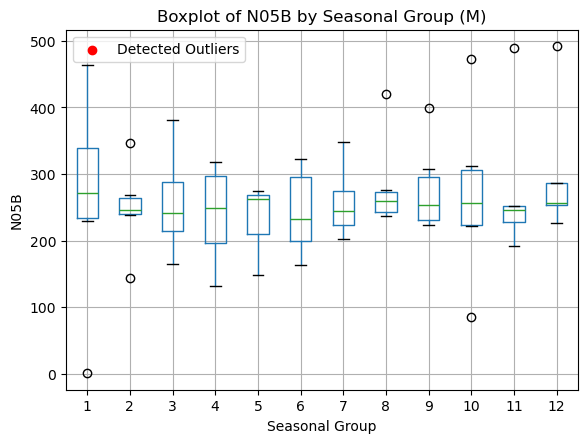

<Figure size 1200x600 with 0 Axes>

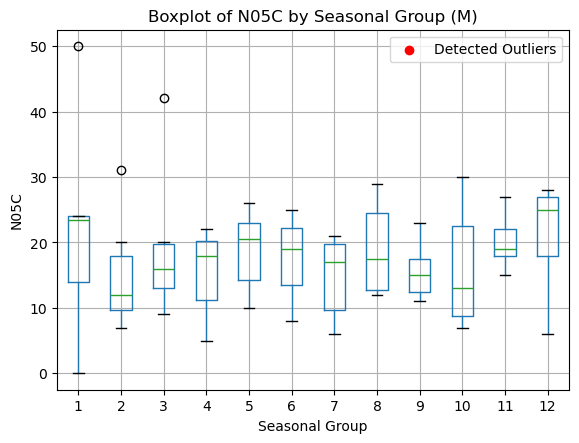

<Figure size 1200x600 with 0 Axes>

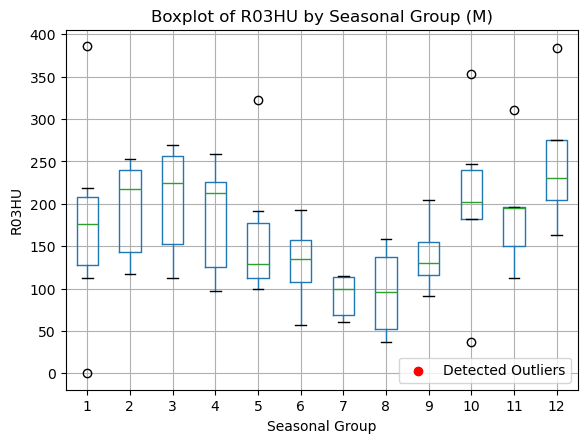

<Figure size 1200x600 with 0 Axes>

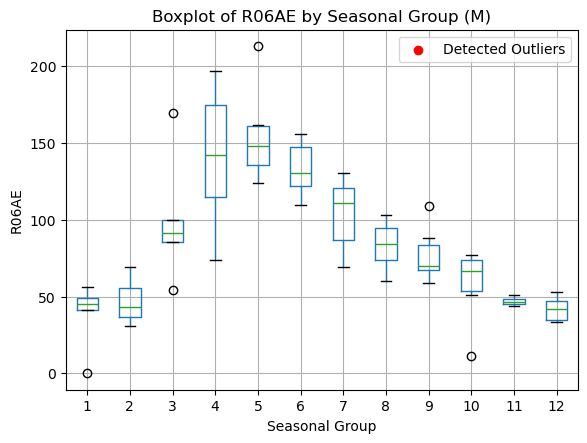

In [16]:

# Frequency mapping
freq_map = {
    "SalesHourly": "H",
    "SalesDaily": "D",
    "SalesWeekly": "W",
    "SalesMonthly": "M",
}

for i in atc_columns:
    salesdaily = detect_and_replace_outliers(salesdaily, i, "D")
for i in atc_columns:
    salesweekly = detect_and_replace_outliers(salesweekly, i, "W")
for i in atc_columns:
    salesmonthly = detect_and_replace_outliers(salesmonthly, i, "M")

In [18]:
saleshourly.to_csv("saleshourly_clean.csv", index=False)
salesdaily.to_csv("salesdaily_clean.csv", index=False)
salesweekly.to_csv("salesweekly_clean.csv", index=False)
salesmonthly.to_csv("salesmonthly_clean.csv", index=False)